**Step 1: Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.optimizers import Adam

**Step 2 :Load MNIST**

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = np.reshape(x_train, (len(x_train),28,28,1))
x_test = np.reshape(x_test, (len(x_test),28,28,1))

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)
(10000, 28, 28, 1)


**Step 3 :Add Noise**

In [3]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

**Step 4:Display Noisy Images**

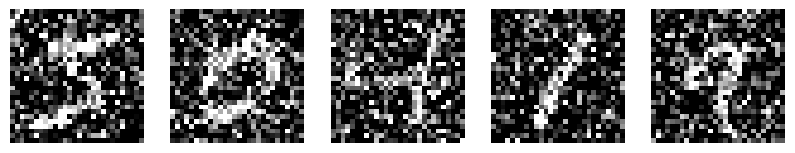

In [4]:
plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()

**Step 5 :Build Autoencoder**

In [5]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(16,(3,3),activation='relu',padding='same')(x)
encoded = MaxPooling2D((2,2),padding='same')(x)

# Decoder
x = Conv2D(16,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)

autoencoder = Model(input_img, decoded)

**Step 6: Compile**

In [6]:
autoencoder.compile(
    optimizer=Adam(),
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

**Step 7:Train**

In [7]:
history = autoencoder.fit(

    x_train_noisy,
    x_train,

    epochs=10,
    batch_size=128,

    shuffle=True,

    validation_data=(
        x_test_noisy,
        x_test
    )
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 232ms/step - loss: 0.1891 - val_loss: 0.1266
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 222ms/step - loss: 0.1226 - val_loss: 0.1169
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 216ms/step - loss: 0.1157 - val_loss: 0.1119
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 217ms/step - loss: 0.1115 - val_loss: 0.1087
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 211ms/step - loss: 0.1089 - val_loss: 0.1070
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 212ms/step - loss: 0.1073 - val_loss: 0.1055
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 215ms/step - loss: 0.1060 - val_loss: 0.1049
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 215ms/step - loss: 0.1048 - val_loss: 0.1031
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 214ms/step - loss: 0.1037 - val_loss: 0.1023
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 214ms/step - loss: 0.1030 - val_loss: 0.1017


**Step 8: Plot Loss**

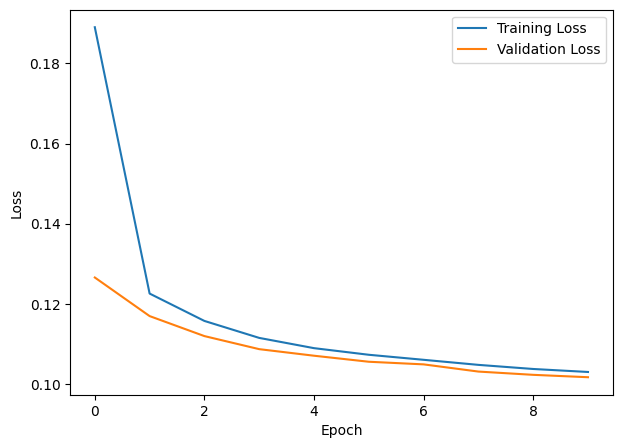

In [8]:
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

**Step 9: Predict**

In [9]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


**Step 10:Compare Results**

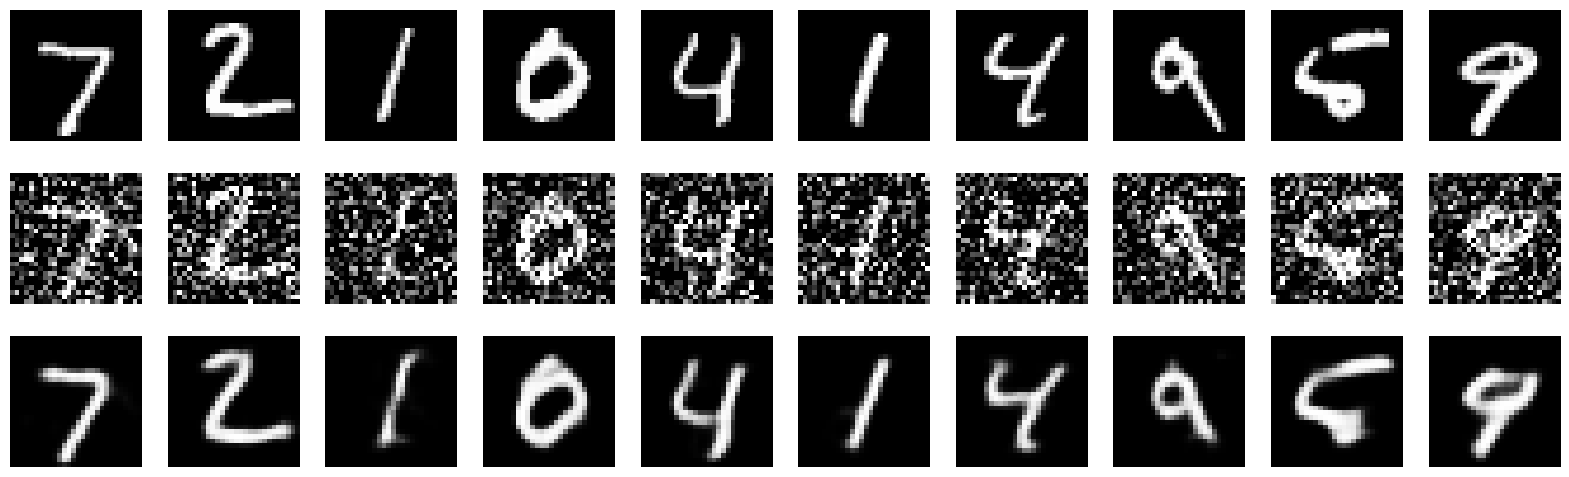

In [14]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Original
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Noisy
    ax = plt.subplot(3,n,i+1+n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3,n,i+1+2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [15]:
autoencoder.save("denoising_autoencoder.keras")

**Observation**


The MNIST dataset was preprocessed by normalizing pixel values to the range [0,1]. Gaussian noise with a noise factor of 0.5 was added to create noisy images. A convolutional denoising autoencoder was designed with encoder and decoder blocks using convolution, max pooling, and upsampling layers. The model was trained using the Adam optimizer and binary cross-entropy loss. After training, the reconstructed images showed significant noise reduction while preserving the digit structure. The training and validation losses decreased consistently, demonstrating effective learning and good denoising performance.